# Heart Failure Data
## By Antara Rajgopal

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, or already established disease) need early detection and management wherein a machine learning model can be of great help.

This model serves as a data insight tool to look into different factors to see the correlation or even causation between the symptoms and the possibility of heart failure. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

heart = pd.read_csv("heart.csv")

In [2]:
heart

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


Figure out the data types for each of the categories!

In [3]:
heart.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

The data is messy right now... substitute the messy values with clean values.

In [4]:
missing_data = heart.isnull().sum()
missing_percent = (heart.isnull().sum() / len(heart)) * 100
missing_info = pd.DataFrame({'Missing Count': missing_data, 'Missing Percentage': missing_percent})

In [5]:
missing_info

,Missing Count,Missing Percentage
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


Find the data of the numerical and categorical columns.

In [6]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
heart[numerical_cols]

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
0,40,140,289,0,172,0.0
1,49,160,180,0,156,1.0
2,37,130,283,0,98,0.0
3,48,138,214,0,108,1.5
4,54,150,195,0,122,0.0
...,...,...,...,...,...,...
913,45,110,264,0,132,1.2
914,68,144,193,1,141,3.4
915,57,130,131,0,115,1.2
916,57,130,236,0,174,0.0


In [7]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
heart[categorical_cols]

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


Target Variable Analysis

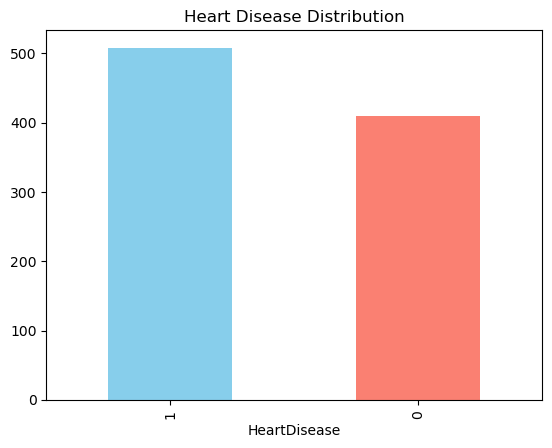

In [8]:
target = heart['HeartDisease'].value_counts()
target.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Heart Disease Distribution')
plt.show()

Numerical features

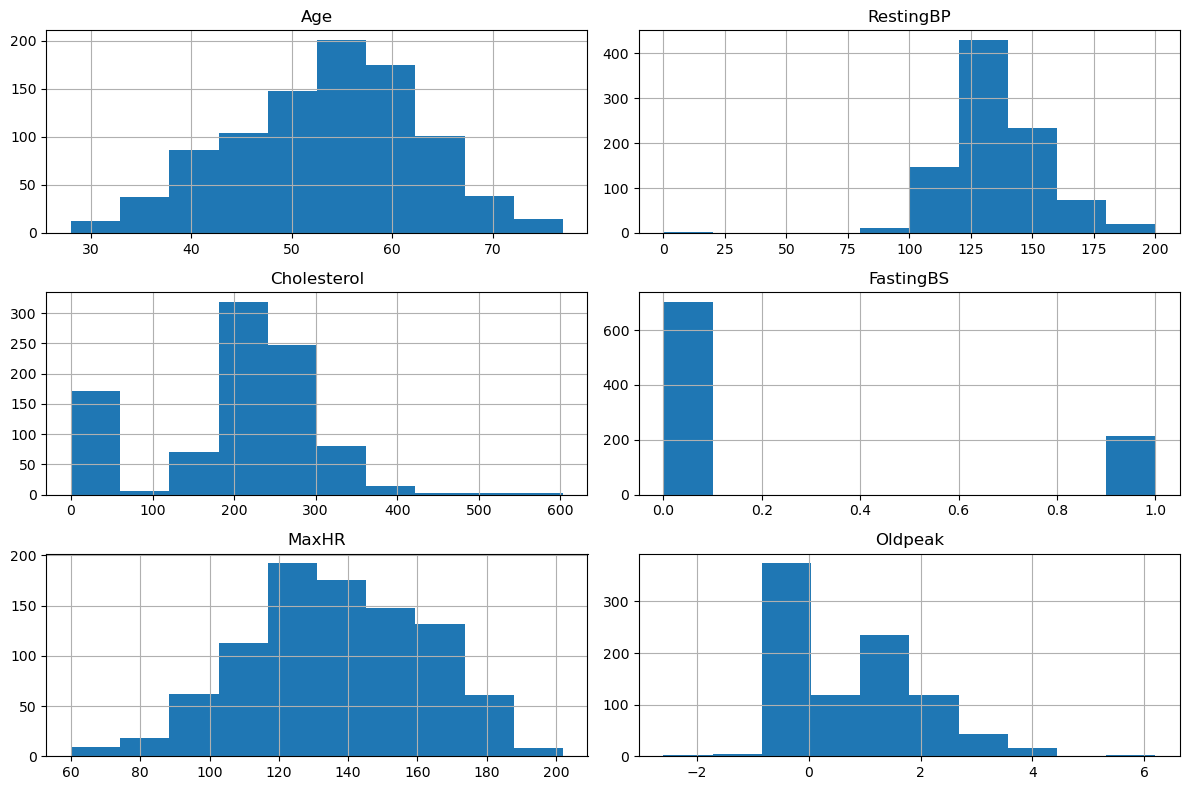

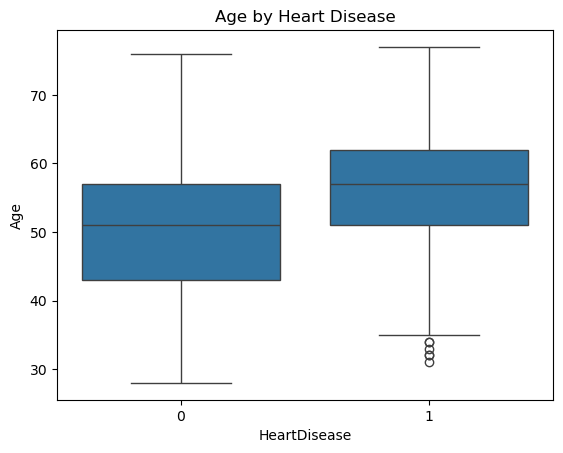

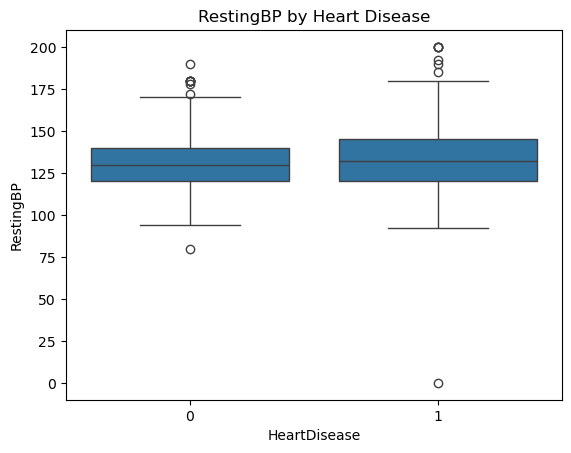

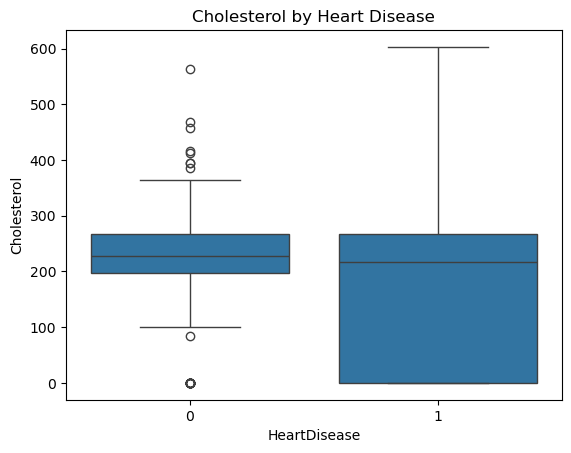

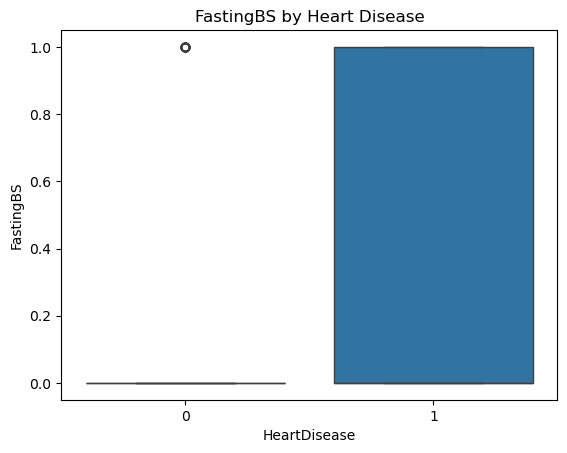

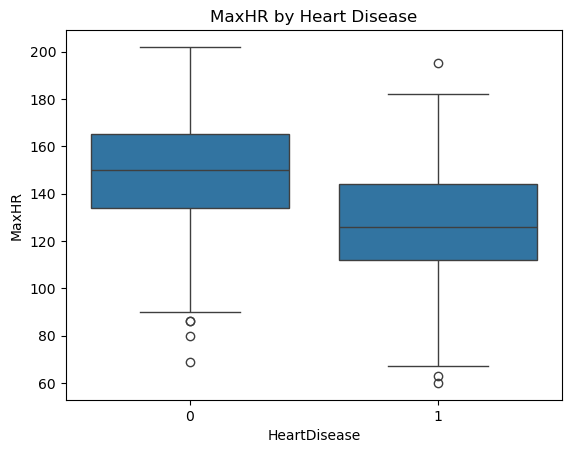

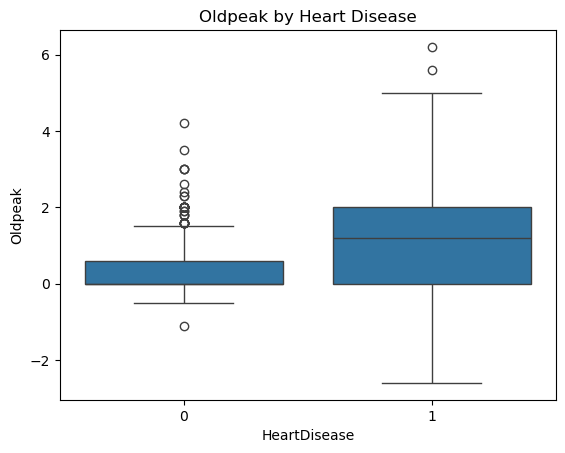

In [9]:
# Histograms
heart[numerical_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Boxplots by target
for num in numerical_cols:
    sns.boxplot(x='HeartDisease', y=num, data=heart)
    plt.title(f'{num} by Heart Disease')
    plt.show()

Categorical features - for analyzing data that cannot be chalked down to numbers.

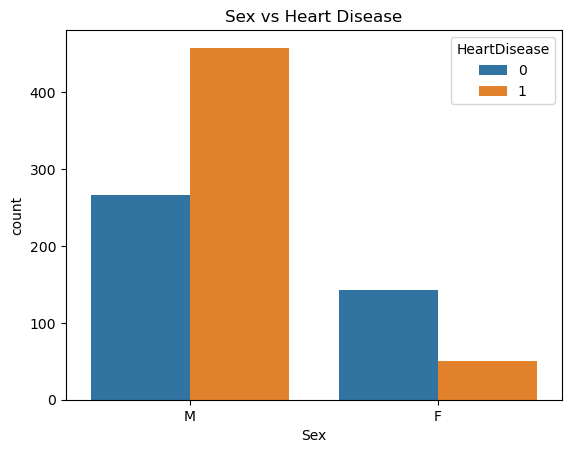

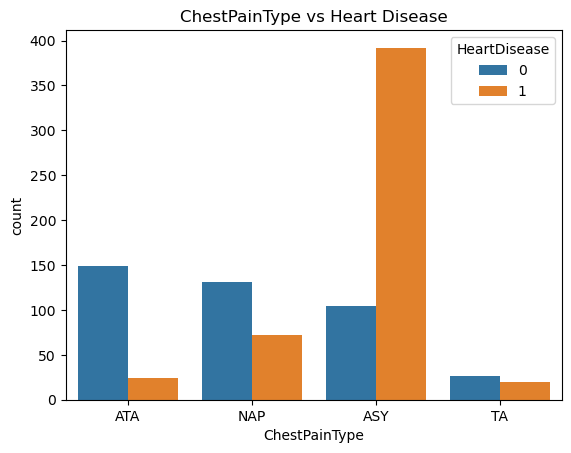

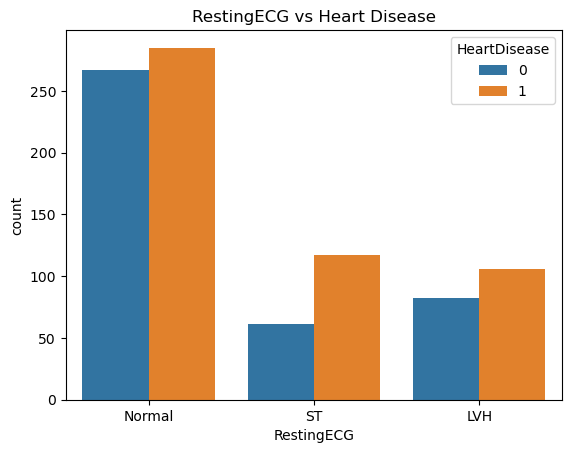

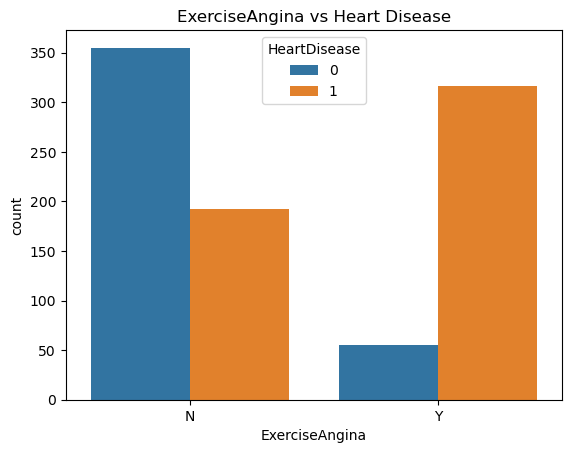

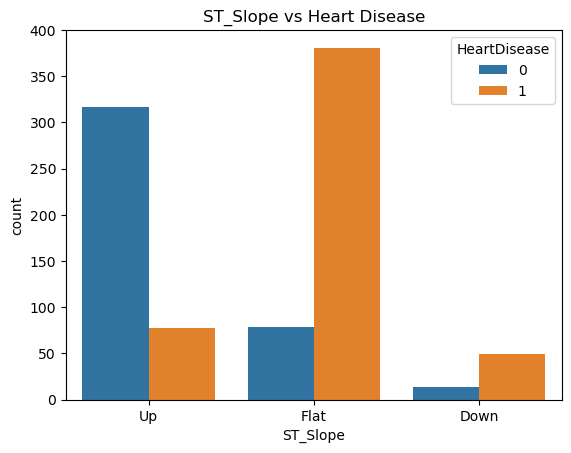

In [10]:
for col in categorical_cols:
    sns.countplot(x=col, data=heart, hue='HeartDisease')
    plt.title(f'{col} vs Heart Disease')
    plt.show()

Correlation - this next part figures out how all these factors could be related to each other.

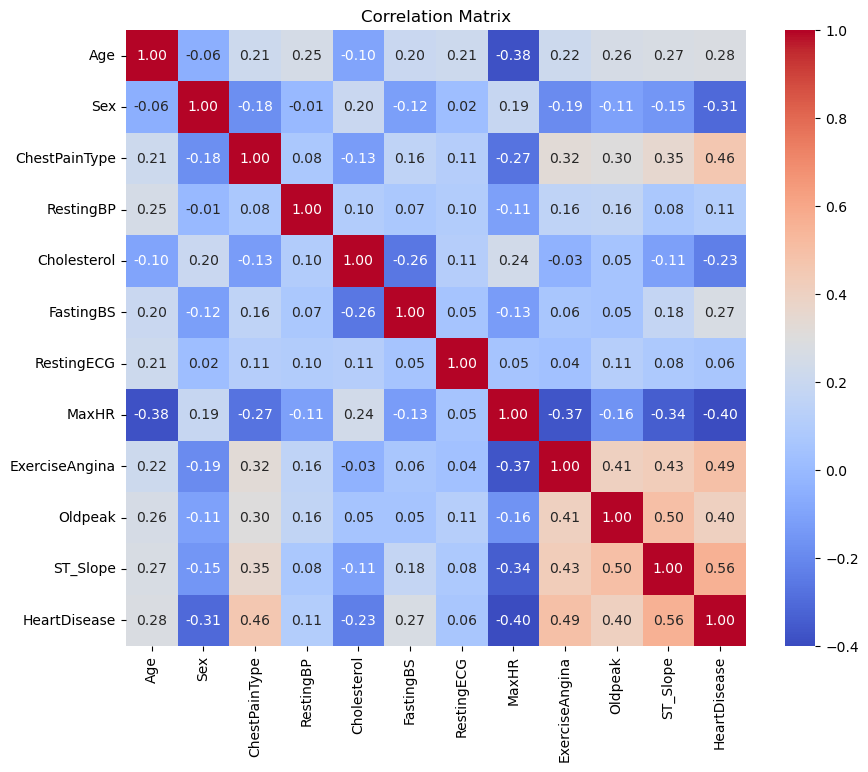

In [11]:
df_encoded = heart.copy()
for c in categorical_cols:
    df_encoded[c] = pd.factorize(df_encoded[c])[0]

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [12]:
for col in numerical_cols:
    Q1, Q3 = heart[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = heart[(heart[col] < Q1 - 1.5 * IQR) | (heart[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
RestingBP: 28 outliers
Cholesterol: 183 outliers
FastingBS: 214 outliers
MaxHR: 2 outliers
Oldpeak: 16 outliers


Some extra data visualization below, such as a pairplot

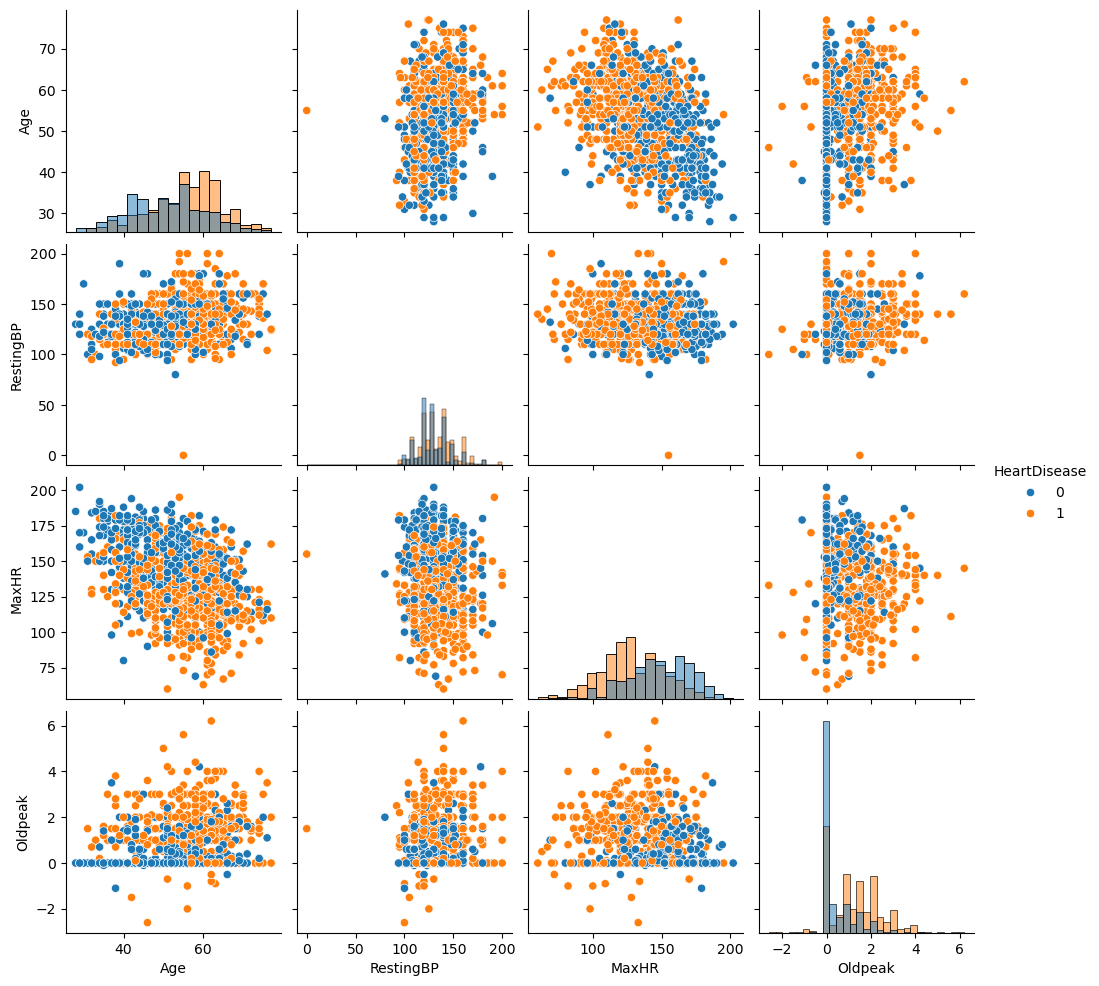

In [13]:
key_features = ['Age', 'RestingBP', 'MaxHR', 'Oldpeak', 'HeartDisease']
sns.pairplot(heart[key_features], hue='HeartDisease', diag_kind='hist')
plt.show()

With all the data we have above, let's do some simple age analysis down below.

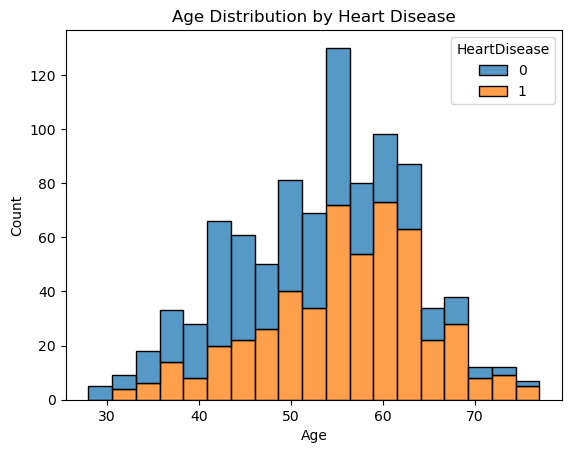

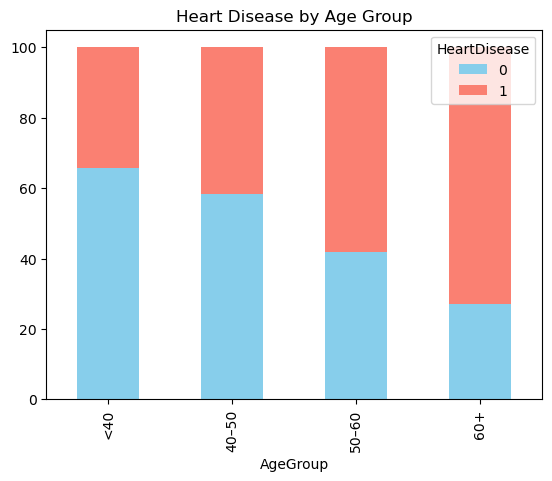

In [14]:
sns.histplot(data=heart, x='Age', hue='HeartDisease', multiple='stack')
plt.title('Age Distribution by Heart Disease')
plt.show()

heart['AgeGroup'] = pd.cut(heart['Age'], [0, 40, 50, 60, 100], labels=['<40', '40–50', '50–60', '60+'])
age_group = pd.crosstab(heart['AgeGroup'], heart['HeartDisease'], normalize='index') * 100
age_group.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Heart Disease by Age Group')
plt.show()

Finally, let's print some simple summary statistics!

In [15]:
print(f"Heart disease rate: {heart['HeartDisease'].mean() * 100:.1f}%")
print("Avg age (No disease):", heart[heart.HeartDisease==0]['Age'].mean())
print("Avg age (Disease):", heart[heart.HeartDisease==1]['Age'].mean())

print("\nHeart disease by gender:")
print(pd.crosstab(heart['Sex'], heart['HeartDisease'], normalize='index') * 100)

print("\nHeart disease by chest pain type:")
print(pd.crosstab(heart['ChestPainType'], heart['HeartDisease'], normalize='index') * 100)

Heart disease rate: 55.3%
Avg age (No disease): 50.551219512195125
Avg age (Disease): 55.8996062992126

Heart disease by gender:
HeartDisease          0          1
Sex                               
F             74.093264  25.906736
M             36.827586  63.172414

Heart disease by chest pain type:
HeartDisease           0          1
ChestPainType                      
ASY            20.967742  79.032258
ATA            86.127168  13.872832
NAP            64.532020  35.467980
TA             56.521739  43.478261


This analysis revealed key patterns associated with heart disease, including strong relationships with age, maximum heart rate, chest pain type, and exercise-induced angina. The dataset was found to be clean with minimal missing values, and outliers were identified in several numerical features. Correlation and distribution analyses highlighted which variables are most relevant to heart disease prediction. These insights provide a solid foundation for feature selection, model development, and further predictive analysis.